In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.anova import AnovaRM
from matplotlib.lines import Line2D
from scipy.stats import t as tdist
from statsmodels.formula.api import glm
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statsmodels.stats.multitest import multipletests
import seaborn as sns

In [3]:
# ----------------- Config -----------------
CSV = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe.csv"

SUBJ  = "SubjectID"
EVENT = "events"
AMP   = "saccade_amplitude_deg"
LEN   = "length"
VAL   = "combinedGazeValidityBitmask"
LONG  = "long_events"
RESID = "ResidualClassAmpDur"   # -1 = fast, 0 = middle, +1 = slow

# ----------------- Load -----------------
df = pd.read_csv(CSV)

for c in [SUBJ, EVENT, AMP, LEN, VAL, LONG, RESID]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------- Valid saccades -----------------
valid = (df[EVENT] == 1.0) & df[AMP].notna() & df[LEN].notna()
valid &= (df[VAL] == 3)
valid &= df[LONG].notna()
valid &= df[RESID].isin([-1, 0, 1])

s = df.loc[valid, [SUBJ, AMP, LEN, RESID]].copy()

# ----------------- Keep only extreme residual classes -----------------
ext = s[s[RESID].isin([-1, +1])].copy()

# ----------------- Count fast and slow per participant -----------------
counts = (
    ext.groupby([SUBJ, RESID])
       .size()
       .unstack(fill_value=0)
       .rename(columns={-1: "n_fast", +1: "n_slow"})
       .reset_index()
)

if "n_fast" not in counts.columns:
    counts["n_fast"] = 0
if "n_slow" not in counts.columns:
    counts["n_slow"] = 0

counts["mean_fast_slow"] = (counts["n_fast"] + counts["n_slow"]) / 2.0
counts["sqrt_mean_fast_slow"] = np.sqrt(counts["mean_fast_slow"])

# ----------------- Summary -----------------
avg_fast = counts["n_fast"].mean()
avg_slow = counts["n_slow"].mean()
avg_of_two_classes = counts["mean_fast_slow"].mean()
sqrt_rule = np.sqrt(avg_of_two_classes)

print("Per-participant counts:")
print(counts.to_string(index=False))

print("\nSummary:")
print(f"Average fast count per participant: {avg_fast:.2f}")
print(f"Average slow count per participant: {avg_slow:.2f}")
print(f"Average of fast/slow counts per participant: {avg_of_two_classes:.2f}")
print(f"Square-root heuristic: {sqrt_rule:.2f}")
print(f"Suggested integer bin count: {int(round(sqrt_rule))}")

Per-participant counts:
 SubjectID  n_fast  n_slow  mean_fast_slow  sqrt_mean_fast_slow
      1031    1339    1276          1307.5            36.159369
      1142    1358    1349          1353.5            36.789944
      1234    1055    1147          1101.0            33.181320
      1268    1261    1307          1284.0            35.832946
      1574    1268    1336          1302.0            36.083237
      1843    1103    1157          1130.0            33.615473
      2069    1302    1299          1300.5            36.062446
      3193    1225    1279          1252.0            35.383612
      3540    1217    1214          1215.5            34.864022
      4580     866     875           870.5            29.504237
      4598    1327    1297          1312.0            36.221541
      4847    1247    1335          1291.0            35.930488
      4875    1273    1305          1289.0            35.902646
      5161    1291    1355          1323.0            36.373067
      5189    12

Amplitude cutpoints (deg) used [class-balanced]:
  Bin 1: [0.00266609, 0.426893)
  Bin 2: [0.426893, 0.668648)
  Bin 3: [0.668648, 0.90747)
  Bin 4: [0.90747, 1.17525)
  Bin 5: [1.17525, 1.45467)
  Bin 6: [1.45467, 1.74978)
  Bin 7: [1.74978, 2.05524)
  Bin 8: [2.05524, 2.3637)
  Bin 9: [2.3637, 2.69092)
  Bin 10: [2.69092, 3.0279)
  Bin 11: [3.0279, 3.39104)
  Bin 12: [3.39104, 3.78372)
  Bin 13: [3.78372, 4.20635)
  Bin 14: [4.20635, 4.64742)
  Bin 15: [4.64742, 5.13734)
  Bin 16: [5.13734, 5.66959)
  Bin 17: [5.66959, 6.20296)
  Bin 18: [6.20296, 6.79484)
  Bin 19: [6.79484, 7.40334)
  Bin 20: [7.40334, 8.11846)
  Bin 21: [8.11846, 8.88268)
  Bin 22: [8.88268, 9.76118)
  Bin 23: [9.76118, 10.7279)
  Bin 24: [10.7279, 11.7711)
  Bin 25: [11.7711, 13.015)
  Bin 26: [13.015, 14.4658)
  Bin 27: [14.4658, 16.2423)
  Bin 28: [16.2423, 18.3297)
  Bin 29: [18.3297, 20.8519)
  Bin 30: [20.8519, 24.0197)
  Bin 31: [24.0197, 28.2708)
  Bin 32: [28.2708, 33.9552)
  Bin 33: [33.9552, 42.186)
  B

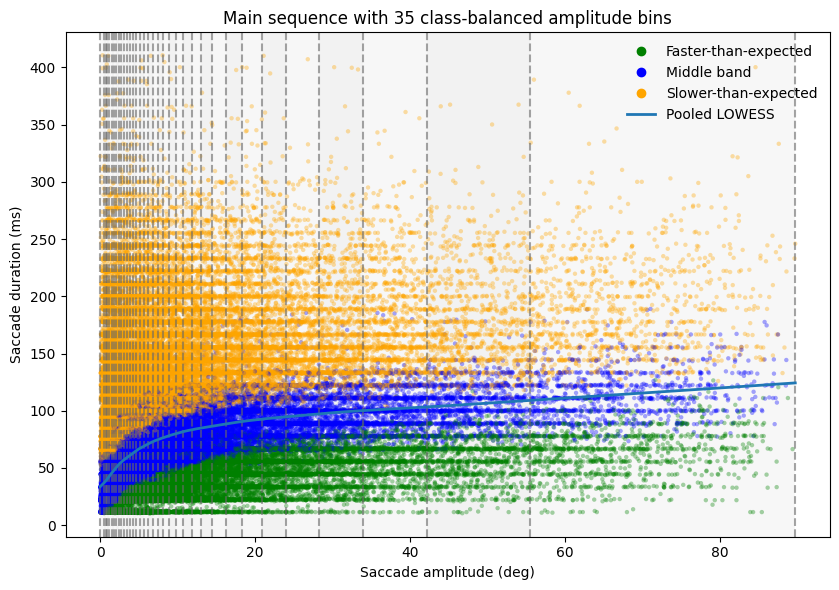

In [7]:
# ===================== Parameters =====================
CSV = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe.csv"
NUM_BINS = 35          
LOWESS_FRAC = 0.20
FIGSIZE = (8.5, 6.0)

# ===================== Column names =====================
EVENT = "events"                    # 1 = saccade onset
AMP = "saccade_amplitude_deg"
LEN = "length"                      # seconds on saccade ONSET row
RESID_CLS = "ResidualClassAmpDur"   # -1 faster, 0 middle, +1 slower
VAL = "combinedGazeValidityBitmask"
LONG = "long_events"

# ===================== Minimal helpers =====================
def weighted_quantile(values, quantiles, sample_weight):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    weights = np.asarray(sample_weight, dtype=float)

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cdf = np.cumsum(weights)
    cdf /= cdf[-1]
    return np.interp(quantiles, cdf, values)

def assign_bins(a, edges):
    """Left-closed, right-open bins; last bin right-closed."""
    idx = np.digitize(np.asarray(a, dtype=float), edges[1:-1], right=False) + 1
    return np.clip(idx, 1, len(edges) - 1)

# ===================== Load and filter =====================
df = pd.read_csv(CSV)
for c in [EVENT, AMP, LEN, RESID_CLS, VAL, LONG]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

valid = (df[EVENT] == 1.0) & df[AMP].notna() & df[LEN].notna()

valid &= (df[VAL] == 3)
valid &= df[LONG].notna()
valid &= df[RESID_CLS].isin([-1, 0, 1])

s = df.loc[valid, [AMP, LEN, RESID_CLS]].copy()
if len(s) < max(10, 2 * NUM_BINS):
    raise ValueError("Not enough valid saccades to form stable bins.")

s["dur_ms"] = s[LEN] * 1000.0

# ===================== Class-balanced edges (extremes only) =====================
ext = s[s[RESID_CLS].isin([-1, +1])]
n_fast = int((ext[RESID_CLS] == -1).sum())
n_slow = int((ext[RESID_CLS] == +1).sum())

q = np.linspace(0.0, 1.0, NUM_BINS + 1)
w = np.where(ext[RESID_CLS].to_numpy() == -1, 0.5 / n_fast, 0.5 / n_slow)
edges = weighted_quantile(ext[AMP].to_numpy(), q, sample_weight=w)

# Strict sanity check: edges must be strictly increasing
if np.unique(edges).size < (NUM_BINS + 1):
    raise ValueError("Bin edges collapsed due to tied amplitudes; reduce NUM_BINS or jitter amplitudes.")

# ===================== Assign bins and validate =====================
s["AmpBin"] = assign_bins(s[AMP].to_numpy(), edges)
counts = np.bincount(s["AmpBin"].to_numpy(), minlength=NUM_BINS + 1)[1:]  # 1..NUM_BINS
if (counts == 0).any():
    empty = np.where(counts == 0)[0] + 1
    raise ValueError(f"Empty bin(s) after assignment: {empty.tolist()}. Reduce NUM_BINS or jitter amplitudes.")

# --- write AmpBin labels back onto df for downstream use ---
df.loc[s.index, "AmpBin"] = s["AmpBin"].astype("Int64")

# ===================== Print edges and counts =====================
print("Amplitude cutpoints (deg) used [class-balanced]:")
for i in range(NUM_BINS):
    left = edges[i]
    right = edges[i + 1]
    right_br = ")" if i < (NUM_BINS - 1) else "]"
    print(f"  Bin {i+1}: [{left:.6g}, {right:.6g}{right_br}")

tab = pd.crosstab(s["AmpBin"], s[RESID_CLS]).rename(columns={-1: "Fast", 0: "Middle band", 1: "Slow"}).sort_index()
tab["Total"] = tab.sum(axis=1)
print("\nCounts per bin × residual class:")
print(tab.to_string())

# quick check of labels on the full df
print("\nLabeled rows in df (non-null AmpBin):", int(df["AmpBin"].notna().sum()))
print("Unique df['AmpBin'] labels:", sorted(df["AmpBin"].dropna().unique()))

# ===================== Plot: main sequence with vertical bands =====================
col_map = {-1: "green", 0: "blue", +1: "orange"}
point_colors = [col_map.get(int(c), "gray") if np.isfinite(c) else "gray" for c in s[RESID_CLS].to_numpy()]

xgrid_pooled = np.array([])
ygrid_pooled = np.array([])
if len(s) >= 5:
    lo = lowess(endog=s["dur_ms"].to_numpy(), exog=s[AMP].to_numpy(), frac=LOWESS_FRAC, return_sorted=True, it=1)
    xgrid_pooled, ygrid_pooled = lo[:, 0], lo[:, 1]

plt.figure(figsize=FIGSIZE)

ymin, ymax = np.nanmin(s["dur_ms"]), np.nanmax(s["dur_ms"])
yr = ymax - ymin if np.isfinite(ymax - ymin) and (ymax - ymin) > 0 else 1.0
pad = 0.05 * yr

# Shaded bands + dashed boundaries
strong_alphas = (0.18, 0.28)
for b in range(NUM_BINS):
    x0, x1 = edges[b], edges[b + 1]
    plt.axvspan(x0, x1, alpha=strong_alphas[b % 2], linewidth=0, color="lightgray")
plt.vlines(edges, ymin=ymin - pad, ymax=ymax + pad, colors="dimgray", linestyles="--", linewidth=1.5, alpha=0.6)

# Scatter + LOWESS
plt.scatter(s[AMP], s["dur_ms"], s=10, alpha=0.35, c=point_colors, edgecolors="none")
if xgrid_pooled.size:
    plt.plot(xgrid_pooled, ygrid_pooled, lw=2, label=f"Pooled LOWESS (frac={LOWESS_FRAC})")

plt.xlabel("Saccade amplitude (deg)")
plt.ylabel("Saccade duration (ms)")
plt.title(f"Main sequence with {NUM_BINS} class-balanced amplitude bins")

legend_elems = [
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, color="green",  label="Faster-than-expected"),
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, color="blue",   label="Middle band"),
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, color="orange", label="Slower-than-expected"),
    Line2D([0],[0], linestyle="-", linewidth=2, color="C0", label="Pooled LOWESS")
]
plt.legend(handles=legend_elems, frameon=False, loc="best")

plt.ylim([ymin - pad, ymax + pad])
plt.tight_layout()
plt.show()


In [9]:
# ===================== Fast/Slow counts per bin + summary =====================
ext_bin = s[s[RESID_CLS].isin([-1, +1])].copy()

bin_counts = (
    ext_bin.groupby(["AmpBin", RESID_CLS])
    .size()
    .unstack(fill_value=0)
    .rename(columns={-1: "Fast", +1: "Slow"})
    .sort_index()
)


bin_counts["Total_extremes"] = bin_counts["Fast"] + bin_counts["Slow"]
bin_counts["Fast_minus_Slow"] = bin_counts["Fast"] - bin_counts["Slow"]

print("\nFast and Slow counts per amplitude bin:")
print(bin_counts.to_string())

# summary values for reporting
fast_mean = bin_counts["Fast"].mean()
fast_sd   = bin_counts["Fast"].std(ddof=1)

slow_mean = bin_counts["Slow"].mean()
slow_sd   = bin_counts["Slow"].std(ddof=1)

total_mean = bin_counts["Total_extremes"].mean()
total_sd   = bin_counts["Total_extremes"].std(ddof=1)

diff_mean = bin_counts["Fast_minus_Slow"].mean()
diff_sd   = bin_counts["Fast_minus_Slow"].std(ddof=1)

print("\nSummary across bins:")
print(f"Fast per bin: M = {fast_mean:.2f}, SD = {fast_sd:.2f}")
print(f"Slow per bin: M = {slow_mean:.2f}, SD = {slow_sd:.2f}")
print(f"Total extreme-class saccades per bin: M = {total_mean:.2f}, SD = {total_sd:.2f}")
print(f"Fast - Slow difference per bin: M = {diff_mean:.2f}, SD = {diff_sd:.2f}")


Fast and Slow counts per amplitude bin:
ResidualClassAmpDur  Fast  Slow  Total_extremes  Fast_minus_Slow
AmpBin                                                          
1                     598  1487            2085             -889
2                     839  1241            2080             -402
3                     869  1210            2079             -341
4                     852  1227            2079             -375
5                     938  1139            2077             -201
6                     980  1096            2076             -116
7                    1021  1055            2076              -34
8                    1098   975            2073              123
9                    1042  1032            2074               10
10                   1083   991            2074               92
11                   1106   967            2073              139
12                   1060  1014            2074               46
13                   1064  1010            2074  

In [ ]:
# Save with AmpBin
df.to_csv(CSV, index=False)